In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.stats as stats

# Asumsi Anda mengunggah satu file per kategori ke Colab
# A = Sehat Mata Terbuka (Z), B = Sehat Mata Tertutup (O), D = Epilepsi Interiktal (F)
file_A = 'Z090.txt' 
file_B = 'O090.txt' 
file_D = 'F090.txt' 

data_A = np.loadtxt(file_A)
data_B = np.loadtxt(file_B)
data_D = np.loadtxt(file_D)

# Konfigurasi frekuensi sampling dari Universitas Bonn
sampling_rate = 173.61 # Hz
waktu = np.arange(len(data_A)) / sampling_rate

In [2]:
print("\nBab 2: Biomedical Signals")
print("EEG Time-Domain Analysis, Power Spectral Density, Statistical Feature Extraction")
print("Kelompok 2 Pengolahan Sinyal Kelas D")
print("Muhammad Danial Irfani/21120123130061")
print("Nicola Adhi Pratama/21120123130076")
print("Nathanael Rico Setiawan/21120123130087")
print("Bambang Irawan/21120123120011")


Bab 2: Biomedical Signals
EEG Time-Domain Analysis, Power Spectral Density, Statistical Feature Extraction
Kelompok 2 Pengolahan Sinyal Kelas D
Muhammad Danial Irfani/21120123130061
Nicola Adhi Pratama/21120123130076
Nathanael Rico Setiawan/21120123130087
Bambang Irawan/21120123120011


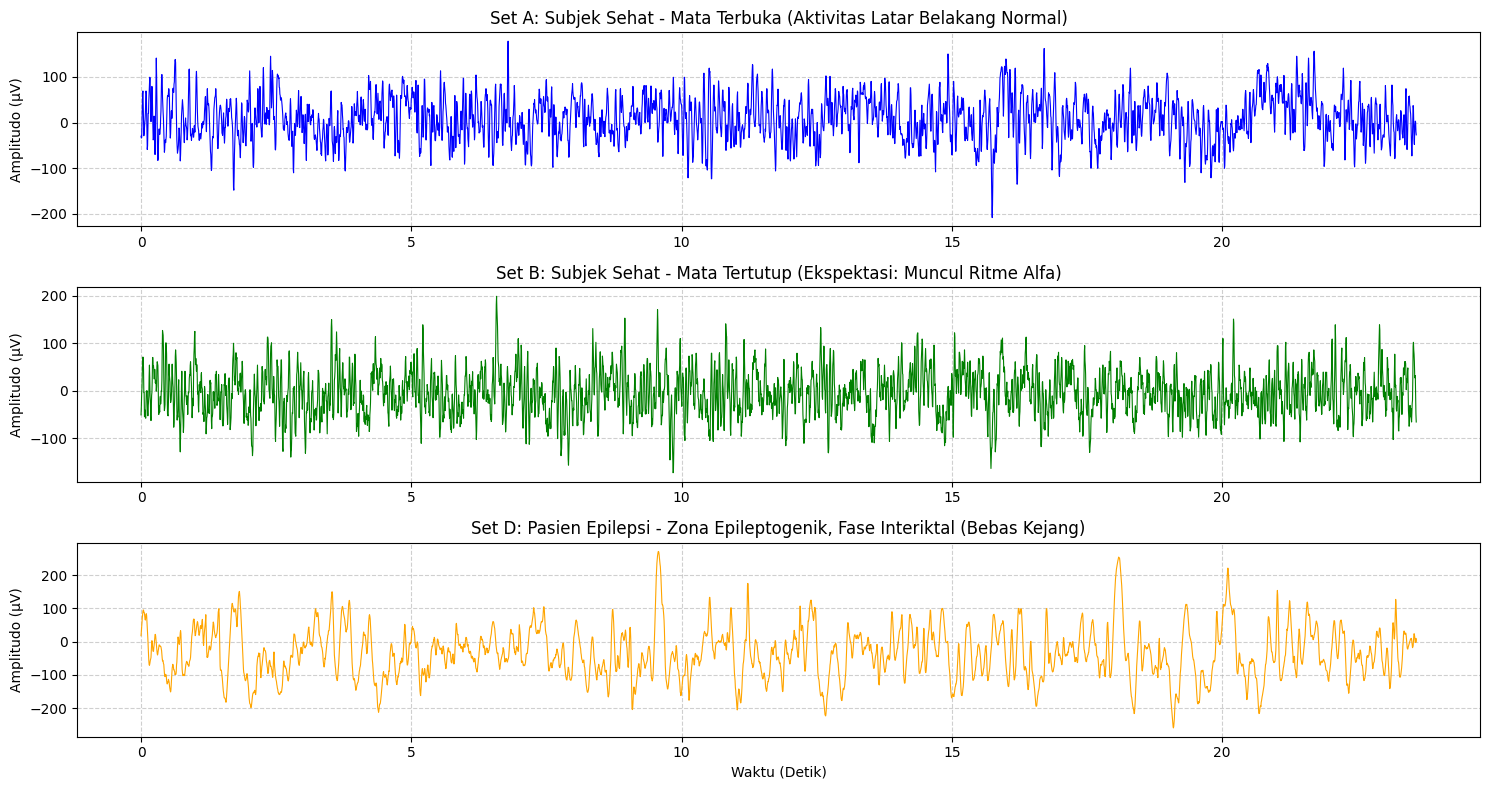

In [3]:
plt.figure(figsize=(15, 8))

# 1. Plot Set A (Normal, Mata Terbuka)
plt.subplot(3, 1, 1)
plt.plot(waktu, data_A, color='blue', linewidth=0.8)
plt.title('Set A: Subjek Sehat - Mata Terbuka (Aktivitas Latar Belakang Normal)')
plt.ylabel('Amplitudo (μV)')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Plot Set B (Normal, Mata Tertutup)
plt.subplot(3, 1, 2)
plt.plot(waktu, data_B, color='green', linewidth=0.8)
plt.title('Set B: Subjek Sehat - Mata Tertutup (Ekspektasi: Muncul Ritme Alfa)')
plt.ylabel('Amplitudo (μV)')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Plot Set D (Epilepsi, Fase Interiktal)
plt.subplot(3, 1, 3)
plt.plot(waktu, data_D, color='orange', linewidth=0.8)
plt.title('Set D: Pasien Epilepsi - Zona Epileptogenik, Fase Interiktal (Bebas Kejang)')
plt.xlabel('Waktu (Detik)')
plt.ylabel('Amplitudo (μV)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

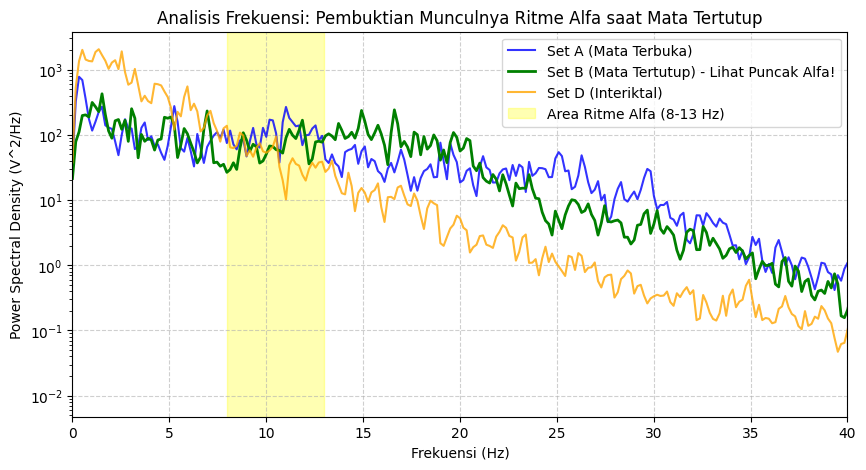

In [4]:
# Menghitung Power Spectral Density (PSD) menggunakan metode Welch
freq_A, psd_A = signal.welch(data_A, fs=sampling_rate, nperseg=1024)
freq_B, psd_B = signal.welch(data_B, fs=sampling_rate, nperseg=1024)
freq_D, psd_D = signal.welch(data_D, fs=sampling_rate, nperseg=1024)

plt.figure(figsize=(10, 5))
plt.semilogy(freq_A, psd_A, label='Set A (Mata Terbuka)', color='blue', alpha=0.8)
plt.semilogy(freq_B, psd_B, label='Set B (Mata Tertutup) - Lihat Puncak Alfa!', color='green', linewidth=2)
plt.semilogy(freq_D, psd_D, label='Set D (Interiktal)', color='orange', alpha=0.8)

# Menyoroti area Ritme Alfa (8-13 Hz)
plt.axvspan(8, 13, color='yellow', alpha=0.3, label='Area Ritme Alfa (8-13 Hz)')

plt.title('Analisis Frekuensi: Pembuktian Munculnya Ritme Alfa saat Mata Tertutup')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Power Spectral Density (V^2/Hz)')
plt.xlim(0, 40) # Fokus pada frekuensi rendah hingga medium
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [5]:
def hitung_fitur(data, nama_set, kondisi):
    return {
        'Dataset': nama_set,
        'Kondisi': kondisi,
        'Standar Deviasi': np.std(data),
        'Varians': np.var(data),
        'Maksimum Absolut': np.max(np.abs(data)) # Mendeteksi lonjakan interictal spikes
    }

df_fitur = pd.DataFrame([
    hitung_fitur(data_A, 'Set A', 'Sehat (Mata Terbuka)'),
    hitung_fitur(data_B, 'Set B', 'Sehat (Mata Tertutup)'),
    hitung_fitur(data_D, 'Set D', 'Epilepsi (Interiktal)')
])

print("Tabel Ekstraksi Fitur Sinyal:")
display(df_fitur)

Tabel Ekstraksi Fitur Sinyal:


,Dataset,Kondisi,Standar Deviasi,Varians,Maksimum Absolut
0,Set A,Sehat (Mata Terbuka),47.667199,2272.161876,208.0
1,Set B,Sehat (Mata Tertutup),47.843244,2288.975954,199.0
2,Set D,Epilepsi (Interiktal),75.690431,5729.041416,271.0
